In [120]:
"""Importing required libraries"""
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
g = torch.Generator().manual_seed(12345)

In [121]:
"""Reading .txt file"""
with open("/home/silver/Desktop/Projects/ML-Algos/Datasets/names.txt", "r") as file:
    content = file.read()
    words = content.splitlines()

In [122]:
"""Vocab Generation"""
stoi = {s:i+1 for i,s in enumerate(sorted(list(set("".join(words)))))}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}

In [123]:
"""Dataset creation"""
X, Y = [], []

block_size = 3

for word in words:
    context = [0]*block_size
    # print(word)
    for i in word+".":
        ix = stoi[i]
        # print("".join([itos[i] for i in context]), "--->", i)
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [ ]:
C = torch.randn((27,2), generator=g, requires_grad=True)

In [ ]:
emb = C[X]

In [ ]:
"""All are the same methods to convert emb shape from [X, 3, 2] to [X, 6]"""
torch.concat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1)
torch.concat(torch.unbind(emb,dim=1), dim=1)
emb.view((-1, 6))

In [ ]:
W1 = torch.randn((6, 100))         # shape must be 6*desired no. of neurons
b1 = torch.randn(100)

In [ ]:
h = (emb.view((-1, 6))@W1 + b1).tanh()

In [ ]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [ ]:
prob = (h@W2 + b2).softmax(1)

In [ ]:
loss = -prob[torch.arange(X.size(0)), Y].log().mean() + 0.01*(W1**2).mean()

## Training Loop

In [132]:
C = torch.randn((27,2), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)         # shape must be 6*desired no. of neurons
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = torch.randn((100, 27), generator=g, requires_grad=True)        # Output should be of size 27 as same as Vocab size
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [133]:
sum(p.nelement() for p in parameters)

3481

### Batch GD

In [ ]:
epochs = 150
lr = 0.1
alpha = 0.01
beta = 0.01
for i in range(epochs):
    """Forward pass"""
    emb = C[X].view(-1, 6)                              # Convert Input tensor to embeddings tensor
    h = (emb@W1 + b1).tanh()                            # First layer of the MLP
    logits = h@W2 + b2                                  # Second layer of the MLP
    loss = F.cross_entropy(logits, Y) + alpha*(W1**2).mean() + beta*(W2**2).mean()              # L2 regularization by adding the square of weights
    
    """Set Grad to 0"""
    for p in parameters:
        p.grad = None
    
    """Backward pass"""
    loss.backward()                                 
    
    """Update parameters"""
    for p in parameters:
        p.data += -lr*p.grad 

print(f"Loss: {loss}")

### Mini-Batch GD

- Faster convergance than Batch GD.
- More fluctuations in the loss than Batch GD

In [134]:
epochs = 5000
lr = 0.1
alpha = 0.01
beta = 0.01

losses = []

for i in range(epochs):
    """Forward pass"""
    idx = torch.randint(0, X.size(0), (256,))
    emb = C[X[idx]].view(-1, 6)
    h = (emb@W1 + b1).tanh()
    logits = h@W2 + b2
    loss = F.cross_entropy(logits, Y[idx])
    losses.append(loss.item())
    
    """Set Grad to 0"""
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    for p in parameters:
        p.data += -lr*p.grad

print(f"Loss: {loss}")

Loss: 2.517153024673462


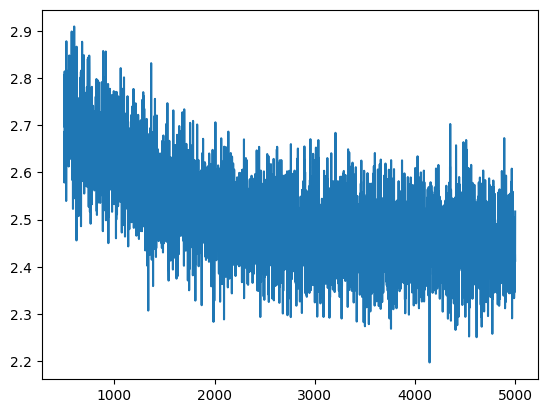

In [139]:
plt.plot(range(500, epochs), losses[500:])
plt.show()

### How to confirm the learning rate range?

- Create a array starting from a range [low, high]. 
- Where low=lr for which loss is not decreasing sharply and high=lr for which loss is fluctuating too much.

In [ ]:
C = torch.randn((27,2), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)         # shape must be 6*desired no. of neurons
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = torch.randn((100, 27), generator=g, requires_grad=True)        # Output should be of size 27 as same as Vocab size
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [ ]:
epochs = 5000
lr = 0.1

# lre = torch.linspace(-3, 0, epochs)
# lrs = 10**lre

losses = []

alpha = 0.01
beta = 0.01
for i in range(epochs):
    """Forward pass"""
    idx = torch.randint(0, X.size(0), (256,))
    emb = C[X[idx]].view(-1, 6)
    h = (emb@W1 + b1).tanh()
    logits = h@W2 + b2
    loss = F.cross_entropy(logits, Y[idx])             # L2 regularization by adding the square of weights
    losses.append(loss.item())
    """Set Grad to 0"""
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    for p in parameters:
        p.data += -lr*p.grad

print(f"Loss: {loss}")

In [140]:
emb = C[X].view(-1, 6)
h = (emb@W1 + b1).tanh()
logits = h@W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.4367, grad_fn=<NllLossBackward0>)

In [ ]:
plt.plot(lre, losses)
plt.show()

In [ ]:
plt.plot(lrs, losses)
plt.show()

In [ ]:
plt.scatter(C[:,0].data, C[:,1].data)
plt.show()

#### Training Set - Used to train parameters
#### Validation Set - Used to train hyperparameters
#### Test Set - Used to test the loss on it

In [155]:
total_rows = X.shape[0]

n1 = int(0.8*total_rows)
n2 = int(0.1*total_rows)

X_train = X[:n1,]
X_val = X[n1:n1+n2,]
X_test = X[n1+n2:,]

Y_train = Y[:n1]
Y_val = Y[n1:n1+n2]
Y_test = Y[n1+n2:]

In [ ]:
C = torch.randn((27,2), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)         # shape must be 6*desired no. of neurons
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = torch.randn((100, 27), generator=g, requires_grad=True)        # Output should be of size 27 as same as Vocab size
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [158]:
epochs = 5000
lr = 0.1
# alpha = 0.01
# beta = 0.01

# losses = []

for i in range(epochs):
    """Forward pass"""
    idx = torch.randint(0, X_train.size(0), (256,))
    emb = C[X_train[idx]].view(-1, 6)
    h = (emb@W1 + b1).tanh()
    logits = h@W2 + b2
    loss = F.cross_entropy(logits, Y_train[idx])
    # losses.append(loss.item())
    
    """Set Grad to 0"""
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    for p in parameters:
        p.data += -lr*p.grad

print(f"Loss: {loss}")

Loss: 2.4215011596679688


In [160]:
"""Loss on train dataset after training"""
emb = C[X_train].view(-1, 6)
h = (emb@W1 + b1).tanh()
logits = h@W2 + b2
loss = F.cross_entropy(logits, Y_train)
print(f"Training Data Loss: {loss}")

Training Data Loss: 2.367037773132324


In [ ]:
"""Loss on validation dataset"""
emb = C[X_val].view(-1, 6)
h = (emb@W1 + b1).tanh()
logits = h@W2 + b2
loss = F.cross_entropy(logits, Y_val)
print(f"Validation Data Loss: {loss}")

Validation Data Loss: 2.5764825344085693


In [ ]:
"""Loss on test dataset"""
emb = C[X_test].view(-1, 6)
h = (emb@W1 + b1).tanh()
logits = h@W2 + b2
loss = F.cross_entropy(logits, Y_test)
print(f"Test Data Loss: {loss}")

Test Data Loss: 2.589498996734619


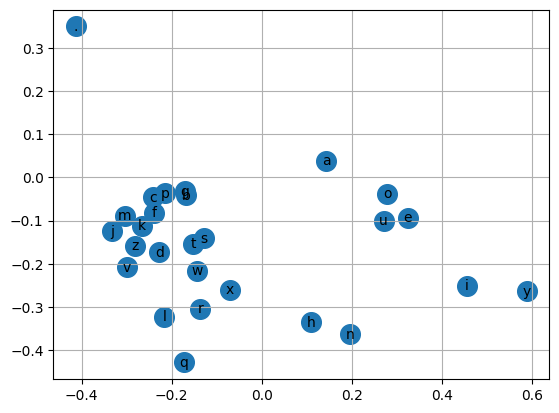

In [171]:
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(len(C[:, 0])):
    plt.text(C[i,0].item(), C[i,1].item(), s=itos[i], ha="center", va="center")
plt.grid("minor")

### Increase Embedding Size

In [179]:
C = torch.randn((27,10), generator=g, requires_grad=True)
W1 = torch.randn((30, 100), generator=g, requires_grad=True)         # shape must be 6*desired no. of neurons
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = torch.randn((100, 27), generator=g, requires_grad=True)        # Output should be of size 27 as same as Vocab size
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [180]:
epochs = 5000
lr = 0.1
# alpha = 0.01
# beta = 0.01

# losses = []

for i in range(epochs):
    """Forward pass"""
    idx = torch.randint(0, X_train.size(0), (256,))
    emb = C[X_train[idx]].view(-1, 30)
    h = (emb@W1 + b1).tanh()
    logits = h@W2 + b2
    loss = F.cross_entropy(logits, Y_train[idx])
    # losses.append(loss.item())
    
    """Set Grad to 0"""
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    for p in parameters:
        p.data += -lr*p.grad

print(f"Loss: {loss}")

Loss: 2.2798123359680176


In [182]:
"""Loss on train dataset after training"""
emb = C[X_train].view(-1, 30)
h = (emb@W1 + b1).tanh()
logits = h@W2 + b2
loss = F.cross_entropy(logits, Y_train)
print(f"Training Data Loss: {loss}")

Training Data Loss: 2.3196277618408203


In [183]:
"""Loss on validation dataset"""
emb = C[X_val].view(-1, 30)
h = (emb@W1 + b1).tanh()
logits = h@W2 + b2
loss = F.cross_entropy(logits, Y_val)
print(f"Validation Data Loss: {loss}")

Validation Data Loss: 2.596778154373169


In [184]:
"""Loss on test dataset"""
emb = C[X_test].view(-1, 30)
h = (emb@W1 + b1).tanh()
logits = h@W2 + b2
loss = F.cross_entropy(logits, Y_test)
print(f"Test Data Loss: {loss}")

Test Data Loss: 2.613431930541992


### Final Predictions

In [192]:
for _ in range(20):
    out = ""
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context])].view(-1, 30)
        # emb = C[X_test].view(-1, 30)
        h = (emb@W1 + b1).tanh()
        logits = h@W2 + b2
        prob = logits.softmax(1)
        ix = torch.multinomial(prob, num_samples=1, replacement=True, generator=g).item()
        context = context[1:] + [ix]

        if ix==0:
            break
            
        out += itos[ix]
    
    print(out)

kol
leio
keli
maxdyn
serazay
izah
sokh
bresen
gra
dyliana
cal
cay
yssuylerissandeal
yasie
natwin
emi
cona
dahla
nay
omgy
